In [2]:
import pandas as pd
import numpy as np

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
INPUT_FILE  = "dse_2008_2022.csv"
OUTPUT_FILE = "dse_engineered.csv"

# ─────────────────────────────────────────────
# 1. LOAD
# ─────────────────────────────────────────────
df = pd.read_csv(INPUT_FILE, parse_dates=["date"])
df.sort_values(["trading_code", "date"], inplace=True)
df.reset_index(drop=True, inplace=True)

# ─────────────────────────────────────────────
# 2. FEATURE ENGINEERING (per stock group)
# ─────────────────────────────────────────────
def engineer(g):
    g = g.copy()

    # Daily Return (%)
    g["daily_return"] = (
        (g["closing_price"] - g["yesterdays_closing_price"])
        / g["yesterdays_closing_price"]
    ) * 100

    # High-Low Spread
    g["high_low_spread"] = g["high"] - g["low"]

    # Intraday Volatility (%)
    g["intraday_volatility"] = (
        (g["high"] - g["low"]) / g["closing_price"]
    ) * 100

    # Volume Change (%)
    g["volume_change_pct"] = g["volume"].pct_change() * 100

    # Price Gap
    g["price_gap"] = g["opening_price"] - g["closing_price"].shift(1)

    # Rolling 5-Day Volatility (std dev of daily returns)
    g["rolling_5d_volatility"] = (
        g["daily_return"].rolling(window=5, min_periods=5).std()
    )

    # Rolling 10-Day Momentum
    g["rolling_10d_momentum"] = (
        g["closing_price"] - g["closing_price"].shift(10)
    )

    return g

print("Engineering features...")
df = df.groupby("trading_code", group_keys=False).apply(engineer)

# ─────────────────────────────────────────────
# 3. LABELING — per-stock statistical thresholds
# ─────────────────────────────────────────────
def compute_thresholds(g):
    mu    = g["daily_return"].mean()
    sigma = g["daily_return"].std()
    p75   = g["intraday_volatility"].quantile(0.75)
    g["_crash_thresh"] = mu - 2 * sigma
    g["_vol_thresh"]   = p75
    return g

print("Computing per-stock thresholds...")
df = df.groupby("trading_code", group_keys=False).apply(compute_thresholds)

# Apply class labels:
# Class 3 = Crash Day      → daily_return < μ - 2σ
# Class 1 = High Volatility → intraday_volatility > P75 (and not crash)
# Class 0 = Normal          → everything else

def assign_label(row):
    if row["daily_return"] < row["_crash_thresh"]:
        return 3   # Crash
    elif row["intraday_volatility"] > row["_vol_thresh"]:
        return 1   # High Volatility
    else:
        return 0   # Normal

print("Assigning class labels...")
df["class"] = df.apply(assign_label, axis=1)

# ─────────────────────────────────────────────
# 4. BUILD FINAL DATASET
# ─────────────────────────────────────────────
# Keep identifiers + engineered features + class only
keep_cols = [
    "date", "trading_code", "sector", "instrument_type",
    "daily_return",
    "high_low_spread",
    "intraday_volatility",
    "volume_change_pct",
    "price_gap",
    "rolling_5d_volatility",
    "rolling_10d_momentum",
    "class"
]

result = df[keep_cols].copy()

# Drop rows where features couldn't be computed (NaN from rolling/shift)
before = len(result)
result.dropna(inplace=True)
after  = len(result)
print(f"Dropped {before - after:,} rows with NaN (rolling window warm-up)")

# ─────────────────────────────────────────────
# 5. SAVE
# ─────────────────────────────────────────────
result.to_csv(OUTPUT_FILE, index=False)

print(f"\n✅ Saved → '{OUTPUT_FILE}'")
print(f"   Total rows   : {len(result):,}")
print(f"   Columns      : {list(result.columns)}")
print(f"\n   Class distribution:")
counts = result["class"].value_counts().sort_index()
labels = {0: "Normal (0)", 1: "High Volatility (1)", 3: "Crash (3)"}
for cls, count in counts.items():
    pct = count / len(result) * 100
    print(f"     {labels[cls]:25s} → {count:>8,}  ({pct:.1f}%)")

Engineering features...


C:\Users\USER\AppData\Local\Temp\ipykernel_25588\2001364056.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("trading_code", group_keys=False).apply(engineer)


Computing per-stock thresholds...


C:\Users\USER\AppData\Roaming\Python\Python313\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\Users\USER\AppData\Roaming\Python\Python313\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\Users\USER\AppData\Roaming\Python\Python313\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\Users\USER\AppData\Roaming\Python\Python313\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\Users\USER\AppData\Roaming\Python\Python313\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\Users\USER\AppData\Roaming\Python\Python313\site-packages

Assigning class labels...
Dropped 783,170 rows with NaN (rolling window warm-up)

✅ Saved → 'dse_engineered.csv'
   Total rows   : 1,007,899
   Columns      : ['date', 'trading_code', 'sector', 'instrument_type', 'daily_return', 'high_low_spread', 'intraday_volatility', 'volume_change_pct', 'price_gap', 'rolling_5d_volatility', 'rolling_10d_momentum', 'class']

   Class distribution:
     Normal (0)                →  752,956  (74.7%)
     High Volatility (1)       →  249,789  (24.8%)
     Crash (3)                 →    5,154  (0.5%)


In [4]:
import pandas as pd
import numpy as np

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
INPUT_FILE  = "dse_engineered.csv"
OUTPUT_FILE = "dse_engineered_v2.csv"

FEATURES = [
    "daily_return",
    "high_low_spread",
    "intraday_volatility",
    "volume_change_pct",
    "price_gap",
    "rolling_5d_volatility",
    "rolling_10d_momentum",
]

# ─────────────────────────────────────────────
# LOAD
# ─────────────────────────────────────────────
print("=" * 60)
print("  MISSING & INFINITE VALUE HANDLER")
print("=" * 60)

df = pd.read_csv(INPUT_FILE, parse_dates=["date"])
print(f"\n[INFO] Loaded {len(df):,} rows × {df.shape[1]} columns")

# ─────────────────────────────────────────────
# STEP 1 — REPORT BEFORE
# ─────────────────────────────────────────────
print("\n── BEFORE Cleaning ──────────────────────────────────────")

# Infinite values
inf_counts = {}
for feat in FEATURES:
    n_inf = np.isinf(df[feat]).sum()
    inf_counts[feat] = n_inf

total_inf = sum(inf_counts.values())
print(f"\n  Infinite values:")
for feat, n in inf_counts.items():
    status = "✅" if n == 0 else "❌"
    print(f"    {status} {feat:30s}: {n:>6,}")
print(f"  Total inf : {total_inf:,}")

# Missing values
nan_counts_before = df[FEATURES].isnull().sum()
total_nan_before  = nan_counts_before.sum()
print(f"\n  Missing (NaN) values:")
for feat, n in nan_counts_before.items():
    status = "✅" if n == 0 else "⚠️ "
    print(f"    {status} {feat:30s}: {n:>6,}")
print(f"  Total NaN : {total_nan_before:,}")

# ─────────────────────────────────────────────
# STEP 2 — REPLACE INF WITH NaN
# ─────────────────────────────────────────────
print("\n── STEP 2: Replace ±Inf with NaN ────────────────────────")
df[FEATURES] = df[FEATURES].replace([np.inf, -np.inf], np.nan)
print(f"  ✅ All ±Inf values converted to NaN.")

# ─────────────────────────────────────────────
# STEP 3 — FILL NaN per stock (forward fill → backward fill)
# Forward fill: use the last known value for that stock
# Backward fill: handles NaN at the very start of a stock's history
# ─────────────────────────────────────────────
print("\n── STEP 3: Fill NaN (forward fill → backward fill) ─────")
print("  Strategy : per trading_code group")
print("             → forward fill (propagate last valid value)")
print("             → backward fill (handle leading NaNs)")

df = df.sort_values(["trading_code", "date"]).reset_index(drop=True)

df[FEATURES] = (
    df.groupby("trading_code")[FEATURES]
    .transform(lambda g: g.ffill().bfill())
)

nan_after_ffill = df[FEATURES].isnull().sum().sum()
print(f"  NaN remaining after ffill+bfill: {nan_after_ffill:,}")

# ─────────────────────────────────────────────
# STEP 4 — FALLBACK: fill any remaining NaN with median
# (handles stocks with ALL NaN in a feature — very rare edge case)
# ─────────────────────────────────────────────
if nan_after_ffill > 0:
    print(f"\n── STEP 4: Fallback — fill remaining NaN with feature median ──")
    for feat in FEATURES:
        n = df[feat].isnull().sum()
        if n > 0:
            median_val = df[feat].median()
            df[feat].fillna(median_val, inplace=True)
            print(f"  ⚠️  {feat:30s}: filled {n:,} with median ({median_val:.4f})")
    print(f"  ✅ Fallback fill complete.")
else:
    print(f"\n── STEP 4: Fallback fill — not needed. ✅")

# ─────────────────────────────────────────────
# STEP 5 — VERIFY
# ─────────────────────────────────────────────
print("\n── STEP 5: Verification ─────────────────────────────────")

nan_final = df[FEATURES].isnull().sum().sum()
inf_final = np.isinf(df[FEATURES].select_dtypes(include=np.number)).sum().sum()

if nan_final == 0:
    print("  ✅ No missing values (NaN) remaining.")
else:
    print(f"  ❌ {nan_final:,} NaN values still remain — check your data.")

if inf_final == 0:
    print("  ✅ No infinite values remaining.")
else:
    print(f"  ❌ {inf_final:,} infinite values still remain.")

# ─────────────────────────────────────────────
# STEP 6 — REPORT AFTER
# ─────────────────────────────────────────────
print("\n── Summary: Before vs After ─────────────────────────────")
print(f"  {'Feature':30s}  {'NaN Before':>12}  {'NaN After':>10}  {'Inf Before':>12}")
for feat in FEATURES:
    print(f"  {feat:30s}  {nan_counts_before[feat]:>12,}  "
          f"{df[feat].isnull().sum():>10,}  {inf_counts[feat]:>12,}")

print(f"\n  Rows before : {len(df):,}")
print(f"  Rows after  : {len(df):,}  (no rows dropped — imputation used)")

# ─────────────────────────────────────────────
# SAVE
# ─────────────────────────────────────────────
df.to_csv(OUTPUT_FILE, index=False)
print(f"\n✅ Saved → '{OUTPUT_FILE}'")
print(f"   Shape  : {df.shape[0]:,} rows × {df.shape[1]} columns")
print("=" * 60)

  MISSING & INFINITE VALUE HANDLER

[INFO] Loaded 1,007,899 rows × 12 columns

── BEFORE Cleaning ──────────────────────────────────────

  Infinite values:
    ✅ daily_return                  :      0
    ✅ high_low_spread               :      0
    ❌ intraday_volatility           :    859
    ❌ volume_change_pct             : 15,560
    ✅ price_gap                     :      0
    ✅ rolling_5d_volatility         :      0
    ✅ rolling_10d_momentum          :      0
  Total inf : 16,419

  Missing (NaN) values:
    ✅ daily_return                  :      0
    ✅ high_low_spread               :      0
    ✅ intraday_volatility           :      0
    ✅ volume_change_pct             :      0
    ✅ price_gap                     :      0
    ✅ rolling_5d_volatility         :      0
    ✅ rolling_10d_momentum          :      0
  Total NaN : 0

── STEP 2: Replace ±Inf with NaN ────────────────────────
  ✅ All ±Inf values converted to NaN.

── STEP 3: Fill NaN (forward fill → backward fill) ──

  DSE ENGINEERED DATASET — VALIDATION REPORT

[INFO] Loaded 1,007,899 rows × 12 columns

── CHECK 1: Missing Values ──────────────────────────────
  ✅ No missing values found in any feature or class column.

── CHECK 2: Class Distribution ──────────────────────────
  Normal (0)               :  752,956  ( 74.7%)  █████████████████████████████████████
  High Volatility (1)      :  249,789  ( 24.8%)  ████████████
  Crash (3)                :    5,154  (  0.5%)  
  ⚠️  CAUTION: Moderate class imbalance (dominant class > 70%). Monitor per-class performance.

── CHECK 3: Outlier Detection (IQR × 3) ─────────────────
  ✅ daily_return                  :  23,805 outliers (2.36%)
  ⚠️  high_low_spread               : 111,016 outliers (11.01%)
  ✅ intraday_volatility           :   5,693 outliers (0.56%)
  ✅ volume_change_pct             :  48,853 outliers (4.85%)
  ❌ price_gap                     : 188,064 outliers (18.66%)
  ✅ rolling_5d_volatility         :   9,180 outliers (0.91%)
  ❌ rolling

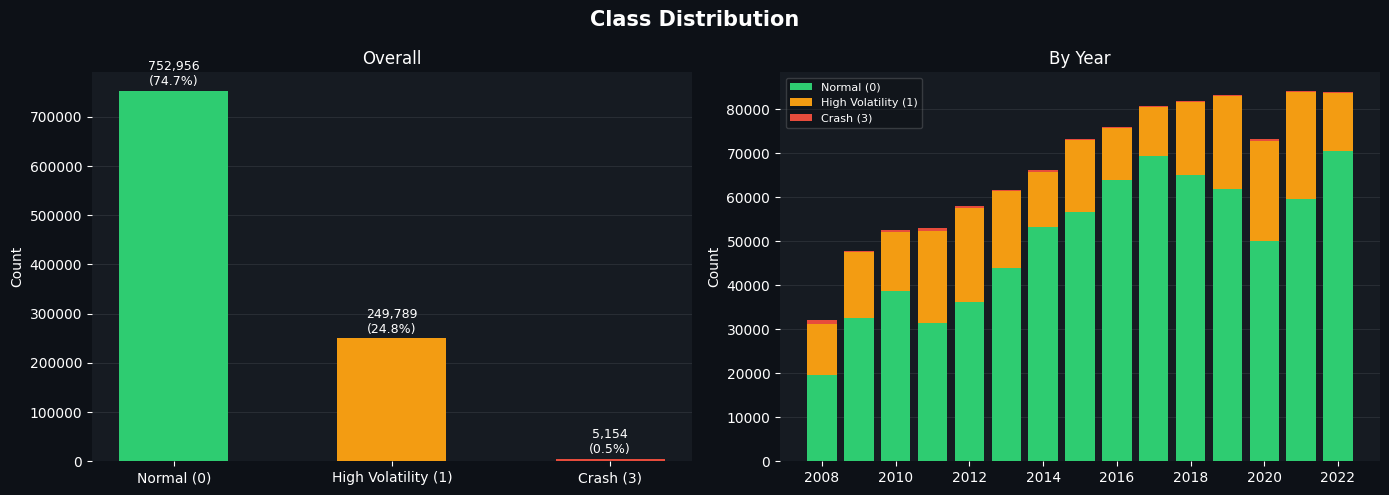

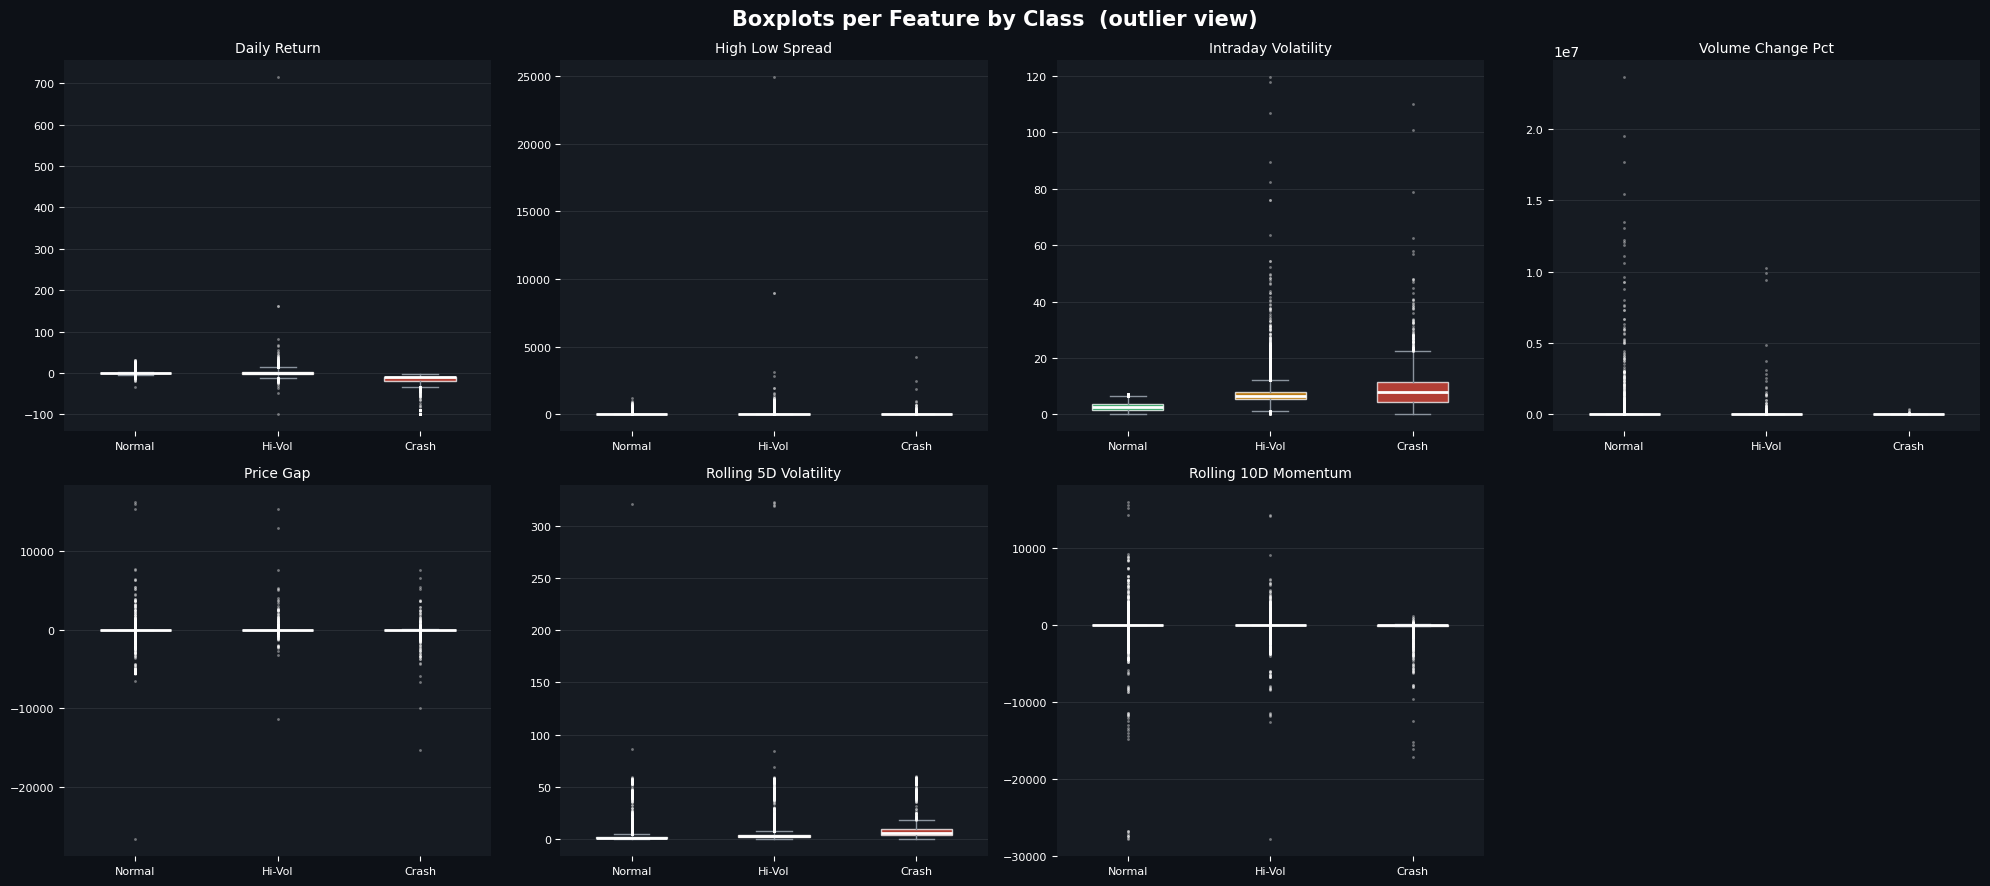

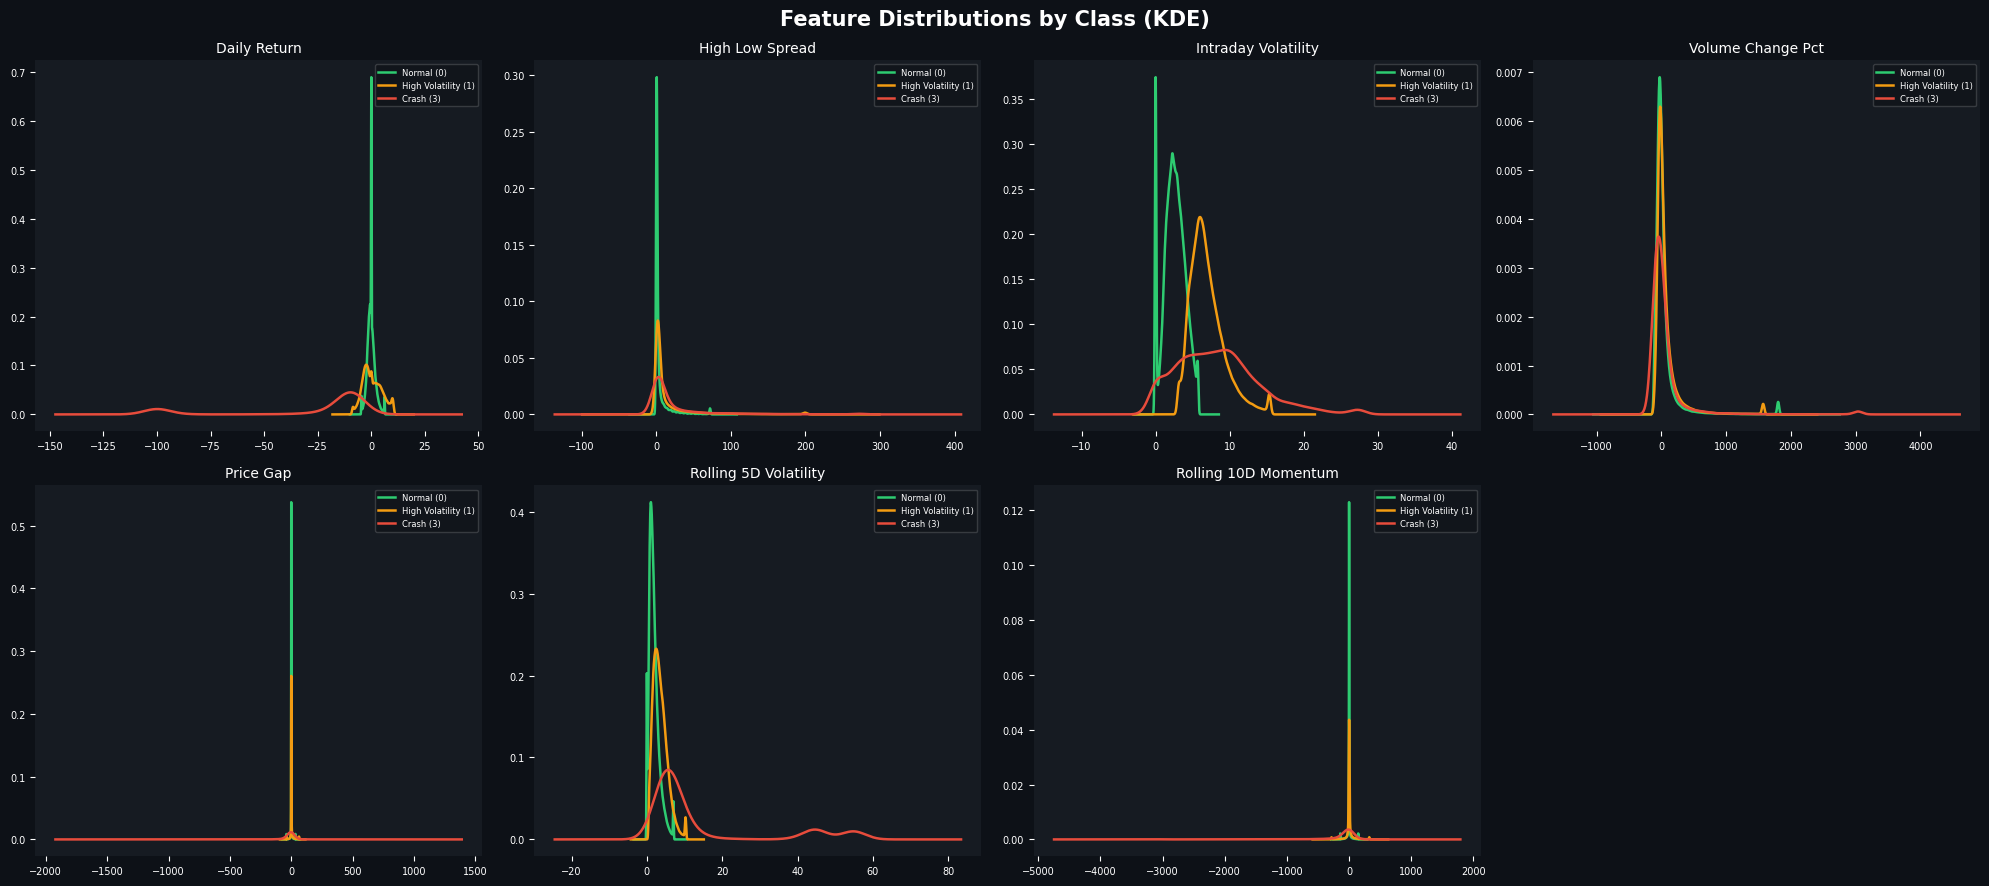

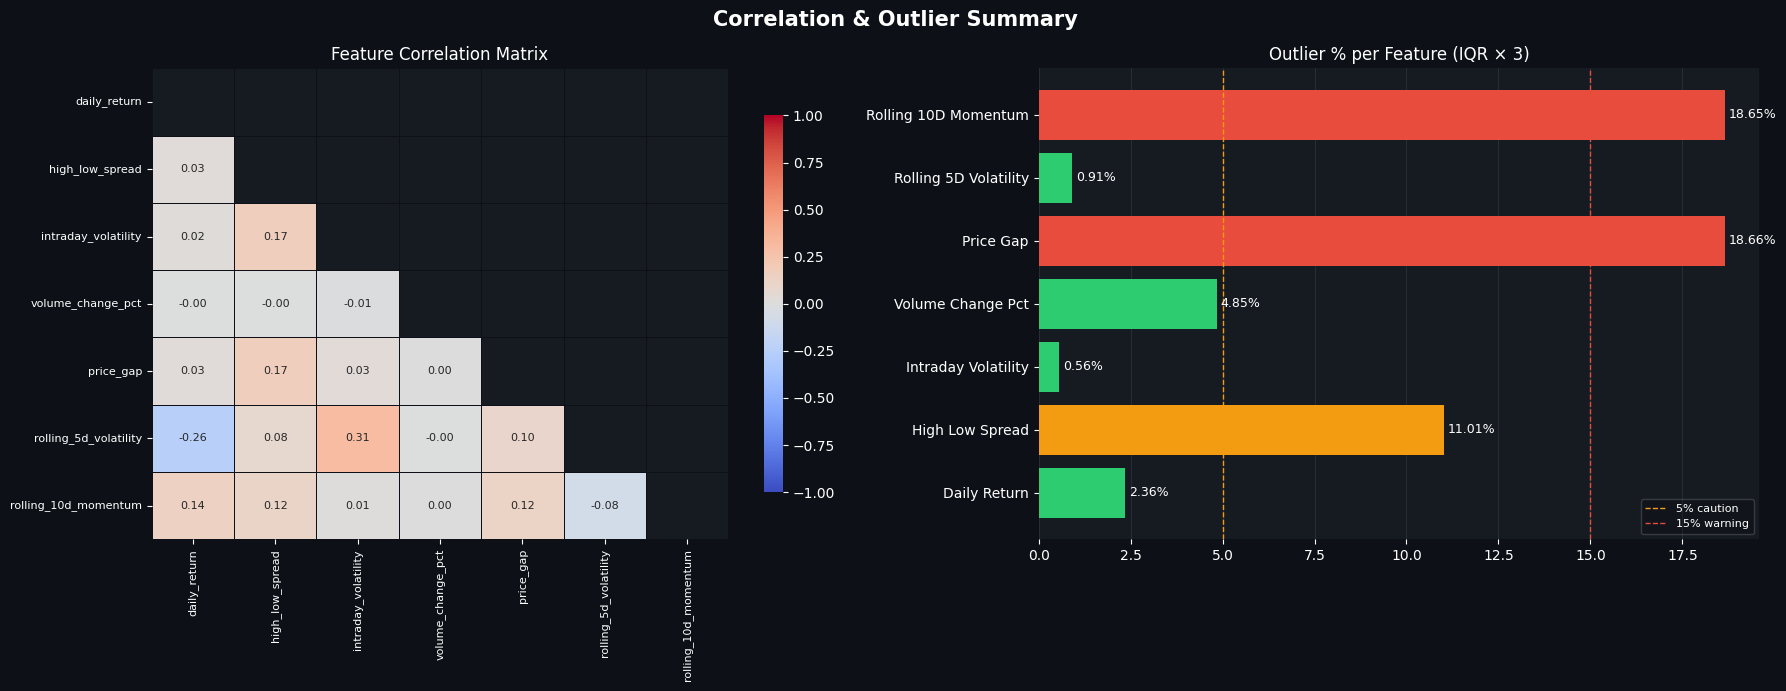

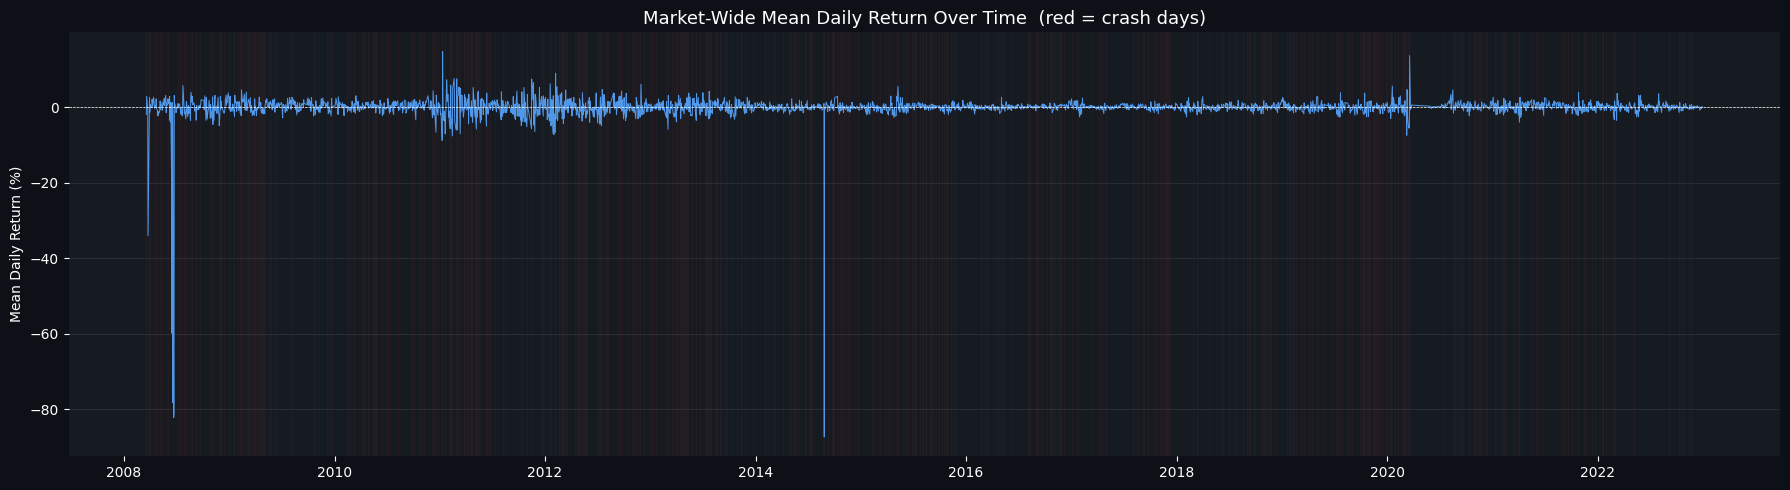


✅ All checks and plots complete.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
INPUT_FILE = "dse_engineered_v2.csv"

FEATURES = [
    "daily_return",
    "high_low_spread",
    "intraday_volatility",
    "volume_change_pct",
    "price_gap",
    "rolling_5d_volatility",
    "rolling_10d_momentum",
]

CLASS_COLORS = {0: "#2ecc71", 1: "#f39c12", 3: "#e74c3c"}
CLASS_LABELS = {0: "Normal (0)", 1: "High Volatility (1)", 3: "Crash (3)"}

# ─────────────────────────────────────────────
# LOAD
# ─────────────────────────────────────────────
print("=" * 60)
print("  DSE ENGINEERED DATASET — VALIDATION REPORT")
print("=" * 60)

df = pd.read_csv(INPUT_FILE, parse_dates=["date"])
print(f"\n[INFO] Loaded {len(df):,} rows × {df.shape[1]} columns")

# ─────────────────────────────────────────────
# CHECK 1 — Missing values
# ─────────────────────────────────────────────
print("\n── CHECK 1: Missing Values ──────────────────────────────")
missing = df[FEATURES + ["class"]].isnull().sum()
if missing.sum() == 0:
    print("  ✅ No missing values found in any feature or class column.")
else:
    print("  ❌ Missing values detected:")
    print(missing[missing > 0].to_string())

# ─────────────────────────────────────────────
# CHECK 2 — Class distribution
# ─────────────────────────────────────────────
print("\n── CHECK 2: Class Distribution ──────────────────────────")
counts = df["class"].value_counts().sort_index()
for cls, cnt in counts.items():
    pct = cnt / len(df) * 100
    bar = "█" * int(pct / 2)
    print(f"  {CLASS_LABELS[cls]:25s}: {cnt:>8,}  ({pct:5.1f}%)  {bar}")

max_pct = counts.max() / len(df) * 100
if max_pct > 85:
    print("  ❌ WARNING: Severe class imbalance (dominant class > 85%). Consider oversampling.")
elif max_pct > 70:
    print("  ⚠️  CAUTION: Moderate class imbalance (dominant class > 70%). Monitor per-class performance.")
else:
    print("  ✅ Class distribution is reasonably balanced.")

# ─────────────────────────────────────────────
# CHECK 3 — Outliers (IQR × 3)
# ─────────────────────────────────────────────
print("\n── CHECK 3: Outlier Detection (IQR × 3) ─────────────────")
outlier_summary = {}
for feat in FEATURES:
    Q1, Q3 = df[feat].quantile(0.25), df[feat].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[feat] < Q1 - 3*IQR) | (df[feat] > Q3 + 3*IQR)).sum()
    pct   = n_out / len(df) * 100
    outlier_summary[feat] = {"count": n_out, "pct": pct}
    status = "✅" if pct < 5 else ("⚠️ " if pct < 15 else "❌")
    print(f"  {status} {feat:30s}: {n_out:>7,} outliers ({pct:.2f}%)")

# ─────────────────────────────────────────────
# CHECK 4 — Feature statistics & skewness
# ─────────────────────────────────────────────
print("\n── CHECK 4: Feature Statistics ──────────────────────────")
stats_df = df[FEATURES].describe().T[["mean", "std", "min", "max"]]
stats_df["skewness"] = df[FEATURES].skew()
print(stats_df.round(4).to_string())

print()
for feat in FEATURES:
    skew = df[feat].skew()
    if abs(skew) > 10:
        print(f"  ❌ {feat}: High skewness ({skew:.2f}) — consider log transform before modeling.")
    elif abs(skew) > 3:
        print(f"  ⚠️  {feat}: Moderate skewness ({skew:.2f})")
    else:
        print(f"  ✅ {feat}: Acceptable skewness ({skew:.2f})")

# ─────────────────────────────────────────────
# CHECK 5 — Date range & coverage
# ─────────────────────────────────────────────
print("\n── CHECK 5: Date Range & Coverage ───────────────────────")
print(f"  Date range   : {df['date'].min().date()}  →  {df['date'].max().date()}")
print(f"  Years present: {sorted(df['date'].dt.year.unique())}")
print(f"  Unique stocks: {df['trading_code'].nunique()}")
missing_years = set(range(2008, 2023)) - set(df["date"].dt.year.unique())
if missing_years:
    print(f"  ⚠️  Missing years: {sorted(missing_years)}")
else:
    print("  ✅ All years 2008–2022 present.")

# ─────────────────────────────────────────────
# PLOTS — show only, no saving
# ─────────────────────────────────────────────
print("\n── Generating plots ──────────────────────────────────────")

plt.style.use("dark_background")
PANEL  = "#161b22"
ACCENT = "#58a6ff"

# ── Figure 1: Class distribution + by year ───────────────
fig1, (ax0, ax1) = plt.subplots(1, 2, figsize=(14, 5), facecolor="#0d1117")
fig1.suptitle("Class Distribution", fontsize=15, color="white", fontweight="bold")

for ax in (ax0, ax1):
    ax.set_facecolor(PANEL)
    ax.spines[:].set_visible(False)
    ax.tick_params(colors="white")
    ax.yaxis.grid(True, color="#30363d", linewidth=0.5)
    ax.set_axisbelow(True)

bars = ax0.bar([CLASS_LABELS[c] for c in counts.index], counts.values,
               color=[CLASS_COLORS[c] for c in counts.index], edgecolor="none", width=0.5)
for bar, val in zip(bars, counts.values):
    ax0.text(bar.get_x() + bar.get_width()/2, bar.get_height() + len(df)*0.005,
             f"{val:,}\n({val/len(df)*100:.1f}%)", ha="center", va="bottom",
             color="white", fontsize=9)
ax0.set_title("Overall", color="white", fontsize=12)
ax0.set_ylabel("Count", color="white")

year_class = df.groupby([df["date"].dt.year, "class"]).size().unstack(fill_value=0)
bottom = np.zeros(len(year_class))
for cls in [0, 1, 3]:
    if cls in year_class.columns:
        ax1.bar(year_class.index, year_class[cls], bottom=bottom,
                label=CLASS_LABELS[cls], color=CLASS_COLORS[cls], edgecolor="none")
        bottom += year_class[cls].values
ax1.set_title("By Year", color="white", fontsize=12)
ax1.set_ylabel("Count", color="white")
ax1.legend(fontsize=8, framealpha=0.2, labelcolor="white")

plt.tight_layout()
plt.show()

# ── Figure 2: Boxplots (outlier view) ────────────────────
fig2, axes = plt.subplots(2, 4, figsize=(20, 9), facecolor="#0d1117")
fig2.suptitle("Boxplots per Feature by Class  (outlier view)", fontsize=15,
              color="white", fontweight="bold")
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    ax = axes[i]
    ax.set_facecolor(PANEL)
    ax.spines[:].set_visible(False)
    ax.tick_params(colors="white", labelsize=8)
    ax.yaxis.grid(True, color="#30363d", linewidth=0.5)
    ax.set_axisbelow(True)

    data_by_class = [df[df["class"] == cls][feat].dropna() for cls in [0, 1, 3]]
    bp = ax.boxplot(data_by_class, patch_artist=True, widths=0.5, notch=False,
                    flierprops=dict(marker=".", color="#ff7b72", markersize=2, alpha=0.4),
                    medianprops=dict(color="white", linewidth=2),
                    whiskerprops=dict(color="#8b949e"),
                    capprops=dict(color="#8b949e"))
    for patch, cls in zip(bp["boxes"], [0, 1, 3]):
        patch.set_facecolor(CLASS_COLORS[cls])
        patch.set_alpha(0.75)
    ax.set_xticklabels(["Normal", "Hi-Vol", "Crash"], color="white", fontsize=8)
    ax.set_title(feat.replace("_", " ").title(), color="white", fontsize=10)

axes[-1].set_visible(False)  # hide unused 8th panel
plt.tight_layout()
plt.show()

# ── Figure 3: KDE distributions ──────────────────────────
fig3, axes = plt.subplots(2, 4, figsize=(20, 9), facecolor="#0d1117")
fig3.suptitle("Feature Distributions by Class (KDE)", fontsize=15,
              color="white", fontweight="bold")
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    ax = axes[i]
    ax.set_facecolor(PANEL)
    ax.spines[:].set_visible(False)
    ax.tick_params(colors="white", labelsize=7)
    ax.yaxis.grid(True, color="#30363d", linewidth=0.5)
    ax.set_axisbelow(True)

    for cls in [0, 1, 3]:
        data = df[df["class"] == cls][feat].dropna()
        data.clip(data.quantile(0.01), data.quantile(0.99)).plot.kde(
            ax=ax, color=CLASS_COLORS[cls], label=CLASS_LABELS[cls], linewidth=1.8)
    ax.set_title(feat.replace("_", " ").title(), color="white", fontsize=10)
    ax.set_ylabel("")
    ax.legend(fontsize=6, framealpha=0.2, labelcolor="white")

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

# ── Figure 4: Correlation heatmap + outlier % ─────────────
fig4, (ax_corr, ax_out) = plt.subplots(1, 2, figsize=(18, 7), facecolor="#0d1117")
fig4.suptitle("Correlation & Outlier Summary", fontsize=15, color="white", fontweight="bold")

ax_corr.set_facecolor(PANEL)
corr = df[FEATURES].corr()
sns.heatmap(corr, ax=ax_corr, mask=np.triu(np.ones_like(corr, dtype=bool)),
            cmap="coolwarm", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 8},
            linewidths=0.5, linecolor="#0d1117",
            cbar_kws={"shrink": 0.8})
ax_corr.set_title("Feature Correlation Matrix", color="white", fontsize=12)
ax_corr.tick_params(colors="white", labelsize=8)

ax_out.set_facecolor(PANEL)
ax_out.spines[:].set_visible(False)
ax_out.tick_params(colors="white")
ax_out.xaxis.grid(True, color="#30363d", linewidth=0.5)
ax_out.set_axisbelow(True)
feat_names = list(outlier_summary.keys())
out_pcts   = [outlier_summary[f]["pct"] for f in feat_names]
colors_out = ["#e74c3c" if p >= 15 else ("#f39c12" if p >= 5 else "#2ecc71") for p in out_pcts]
bars2 = ax_out.barh([f.replace("_", " ").title() for f in feat_names],
                    out_pcts, color=colors_out, edgecolor="none")
for bar, pct in zip(bars2, out_pcts):
    ax_out.text(pct + 0.1, bar.get_y() + bar.get_height()/2,
                f"{pct:.2f}%", va="center", color="white", fontsize=9)
ax_out.axvline(5,  color="#f39c12", linestyle="--", linewidth=1, label="5% caution")
ax_out.axvline(15, color="#e74c3c", linestyle="--", linewidth=1, label="15% warning")
ax_out.set_title("Outlier % per Feature (IQR × 3)", color="white", fontsize=12)
ax_out.legend(fontsize=8, framealpha=0.2, labelcolor="white")

plt.tight_layout()
plt.show()

# ── Figure 5: Market mean daily return time series ────────
fig5, ax_ts = plt.subplots(figsize=(18, 5), facecolor="#0d1117")
ax_ts.set_facecolor(PANEL)
ax_ts.spines[:].set_visible(False)
ax_ts.tick_params(colors="white")
ax_ts.yaxis.grid(True, color="#30363d", linewidth=0.5)
ax_ts.set_axisbelow(True)

daily_mean = df.groupby("date")["daily_return"].mean()
ax_ts.plot(daily_mean.index, daily_mean.values, color=ACCENT, linewidth=0.7, alpha=0.9)
ax_ts.axhline(0, color="white", linewidth=0.5, linestyle="--")
for d in df[df["class"] == 3]["date"].unique():
    ax_ts.axvspan(d, d + pd.Timedelta(days=1), color="#e74c3c", alpha=0.06, linewidth=0)
ax_ts.set_title("Market-Wide Mean Daily Return Over Time  (red = crash days)",
                color="white", fontsize=13)
ax_ts.set_ylabel("Mean Daily Return (%)", color="white")

plt.tight_layout()
plt.show()

print("\n✅ All checks and plots complete.")
print("=" * 60)

In [7]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
INPUT_FILE = "dse_engineered_v2.csv"

FEATURES = [
    "daily_return",
    "high_low_spread",
    "intraday_volatility",
    "volume_change_pct",
    "price_gap",
    "rolling_5d_volatility",
    "rolling_10d_momentum",
]

CLASS_LABELS = {0: "Normal", 1: "High Volatility", 3: "Crash"}

# ─────────────────────────────────────────────
# LOAD
# ─────────────────────────────────────────────
df = pd.read_csv(INPUT_FILE, parse_dates=["date"])

print("=" * 65)
print("  DATASET QUALITY REPORT — dataset_v2.csv")
print("=" * 65)
print(f"\n  Rows    : {len(df):,}")
print(f"  Columns : {df.shape[1]}")
print(f"  Memory  : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# ─────────────────────────────────────────────
# CHECK 1 — Missing Values
# ─────────────────────────────────────────────
print("\n── CHECK 1: Missing Values ──────────────────────────────")
missing = df[FEATURES + ["class"]].isnull().sum()
total_missing = missing.sum()
for col, n in missing.items():
    status = "✅" if n == 0 else "❌"
    print(f"  {status} {col:30s}: {n:,}")
if total_missing == 0:
    print(f"\n  ✅ PASS — Zero missing values across all features.")
else:
    print(f"\n  ❌ FAIL — {total_missing:,} missing values found.")

# ─────────────────────────────────────────────
# CHECK 2 — Infinite Values
# ─────────────────────────────────────────────
print("\n── CHECK 2: Infinite Values ─────────────────────────────")
total_inf = 0
for feat in FEATURES:
    n = np.isinf(df[feat]).sum()
    total_inf += n
    status = "✅" if n == 0 else "❌"
    print(f"  {status} {feat:30s}: {n:,}")
if total_inf == 0:
    print(f"\n  ✅ PASS — Zero infinite values across all features.")
else:
    print(f"\n  ❌ FAIL — {total_inf:,} infinite values found.")

# ─────────────────────────────────────────────
# CHECK 3 — Duplicate Rows
# ─────────────────────────────────────────────
print("\n── CHECK 3: Duplicate Rows ──────────────────────────────")
dupes = df.duplicated(subset=["date", "trading_code"]).sum()
if dupes == 0:
    print(f"  ✅ PASS — No duplicate (date, trading_code) pairs found.")
else:
    print(f"  ❌ FAIL — {dupes:,} duplicate rows found.")

# ─────────────────────────────────────────────
# CHECK 4 — Class Distribution
# ─────────────────────────────────────────────
print("\n── CHECK 4: Class Distribution ──────────────────────────")
counts = df["class"].value_counts().sort_index()
for cls, cnt in counts.items():
    pct = cnt / len(df) * 100
    bar = "█" * int(pct / 2)
    print(f"  Class {cls} — {CLASS_LABELS.get(cls,'?'):15s}: {cnt:>8,}  ({pct:5.1f}%)  {bar}")

max_pct = counts.max() / len(df) * 100
print()
if max_pct > 85:
    print(f"  ❌ FAIL — Severe class imbalance. Dominant class = {max_pct:.1f}%.")
    print(f"     → Apply SMOTE or class weights before modeling.")
elif max_pct > 70:
    print(f"  ⚠️  CAUTION — Moderate imbalance. Dominant class = {max_pct:.1f}%.")
    print(f"     → Monitor per-class F1 score during evaluation.")
else:
    print(f"  ✅ PASS — Class distribution is acceptable.")

# ─────────────────────────────────────────────
# CHECK 5 — Feature Statistics
# ─────────────────────────────────────────────
print("\n── CHECK 5: Feature Statistics ──────────────────────────")
print(f"\n  {'Feature':<30} {'Mean':>10} {'Std':>10} {'Min':>12} {'Max':>12} {'Skew':>8}")
print(f"  {'-'*30} {'-'*10} {'-'*10} {'-'*12} {'-'*12} {'-'*8}")
for feat in FEATURES:
    mean = df[feat].mean()
    std  = df[feat].std()
    mn   = df[feat].min()
    mx   = df[feat].max()
    skew = df[feat].skew()
    print(f"  {feat:<30} {mean:>10.4f} {std:>10.4f} {mn:>12.4f} {mx:>12.4f} {skew:>8.2f}")

# ─────────────────────────────────────────────
# CHECK 6 — Skewness
# ─────────────────────────────────────────────
print("\n── CHECK 6: Skewness Check ──────────────────────────────")
for feat in FEATURES:
    skew = df[feat].skew()
    if abs(skew) > 10:
        print(f"  ❌ {feat:30s}: skew = {skew:>8.2f}  → High — log transform recommended")
    elif abs(skew) > 3:
        print(f"  ⚠️  {feat:30s}: skew = {skew:>8.2f}  → Moderate")
    else:
        print(f"  ✅ {feat:30s}: skew = {skew:>8.2f}  → Acceptable")

# ─────────────────────────────────────────────
# CHECK 7 — Outliers (IQR × 3)
# ─────────────────────────────────────────────
print("\n── CHECK 7: Outliers (IQR × 3) ──────────────────────────")
for feat in FEATURES:
    Q1, Q3 = df[feat].quantile(0.25), df[feat].quantile(0.75)
    IQR    = Q3 - Q1
    n_out  = ((df[feat] < Q1 - 3*IQR) | (df[feat] > Q3 + 3*IQR)).sum()
    pct    = n_out / len(df) * 100
    if pct >= 15:
        status = "❌"
        note   = "→ High — review feature or apply capping"
    elif pct >= 5:
        status = "⚠️ "
        note   = "→ Moderate — acceptable for financial data"
    else:
        status = "✅"
        note   = "→ Low"
    print(f"  {status} {feat:30s}: {n_out:>7,}  ({pct:5.2f}%)  {note}")

# ─────────────────────────────────────────────
# CHECK 8 — Date & Year Coverage
# ─────────────────────────────────────────────
print("\n── CHECK 8: Date & Year Coverage ────────────────────────")
years_present = sorted(df["date"].dt.year.unique())
missing_years = sorted(set(range(2008, 2023)) - set(years_present))
print(f"  Date range    : {df['date'].min().date()}  →  {df['date'].max().date()}")
print(f"  Years present : {years_present}")
print(f"  Unique stocks : {df['trading_code'].nunique():,}")
if missing_years:
    print(f"  ❌ Missing years: {missing_years}")
else:
    print(f"  ✅ PASS — All years 2008–2022 present.")

# ─────────────────────────────────────────────
# CHECK 9 — Negative values in non-negative features
# ─────────────────────────────────────────────
print("\n── CHECK 9: Negative Values in Non-Negative Features ────")
non_negative = ["high_low_spread", "intraday_volatility", "rolling_5d_volatility"]
for feat in non_negative:
    n_neg = (df[feat] < 0).sum()
    status = "✅" if n_neg == 0 else "❌"
    print(f"  {status} {feat:30s}: {n_neg:,} negative values")

# ─────────────────────────────────────────────
# CHECK 10 — Per-class feature mean (sanity check)
# ─────────────────────────────────────────────
print("\n── CHECK 10: Per-Class Feature Means (Sanity Check) ─────")
print(f"\n  {'Feature':<30} {'Normal (0)':>12} {'Hi-Vol (1)':>12} {'Crash (3)':>12}")
print(f"  {'-'*30} {'-'*12} {'-'*12} {'-'*12}")
for feat in FEATURES:
    means = df.groupby("class")[feat].mean()
    v0 = means.get(0, float("nan"))
    v1 = means.get(1, float("nan"))
    v3 = means.get(3, float("nan"))
    print(f"  {feat:<30} {v0:>12.4f} {v1:>12.4f} {v3:>12.4f}")

print(f"\n  ℹ️  Expected pattern:")
print(f"      daily_return       : Normal > Hi-Vol > Crash (crash should be most negative)")
print(f"      intraday_volatility: Crash > Hi-Vol > Normal")
print(f"      rolling_5d_volatility: Crash > Hi-Vol > Normal")

# ─────────────────────────────────────────────
# FINAL VERDICT
# ─────────────────────────────────────────────
print("\n" + "=" * 65)
print("  FINAL VERDICT")
print("=" * 65)

issues = []
if total_missing > 0:        issues.append("Missing values present")
if total_inf > 0:            issues.append("Infinite values present")
if dupes > 0:                issues.append("Duplicate rows present")
if missing_years:            issues.append(f"Missing years: {missing_years}")
for feat in non_negative:
    if (df[feat] < 0).sum() > 0:
        issues.append(f"Negative values in {feat}")

if not issues:
    print("\n  ✅ DATA IS CLEAN AND READY FOR MODELING")
    print("\n  All critical checks passed:")
    print("     • No missing values")
    print("     • No infinite values")
    print("     • No duplicate rows")
    print("     • Full year coverage 2008–2022")
    print("     • No invalid negatives in non-negative features")
    if max_pct > 70:
        print(f"\n  ⚠️  One advisory note:")
        print(f"     • Class imbalance exists ({max_pct:.1f}% dominant class)")
        print(f"       → Use SMOTE / class_weight='balanced' before training")
else:
    print("\n  ❌ DATA HAS ISSUES — DO NOT MODEL YET")
    print("\n  Problems found:")
    for issue in issues:
        print(f"     • {issue}")

print("\n" + "=" * 65)

  DATASET QUALITY REPORT — dataset_v2.csv

  Rows    : 1,007,899
  Columns : 12
  Memory  : 236.34 MB

── CHECK 1: Missing Values ──────────────────────────────
  ✅ daily_return                  : 0
  ✅ high_low_spread               : 0
  ✅ intraday_volatility           : 0
  ✅ volume_change_pct             : 0
  ✅ price_gap                     : 0
  ✅ rolling_5d_volatility         : 0
  ✅ rolling_10d_momentum          : 0
  ✅ class                         : 0

  ✅ PASS — Zero missing values across all features.

── CHECK 2: Infinite Values ─────────────────────────────
  ✅ daily_return                  : 0
  ✅ high_low_spread               : 0
  ✅ intraday_volatility           : 0
  ✅ volume_change_pct             : 0
  ✅ price_gap                     : 0
  ✅ rolling_5d_volatility         : 0
  ✅ rolling_10d_momentum          : 0

  ✅ PASS — Zero infinite values across all features.

── CHECK 3: Duplicate Rows ──────────────────────────────
  ❌ FAIL — 1,092 duplicate rows found.

── C

In [8]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
INPUT_FILE  = "dse_engineered_v2.csv"
OUTPUT_FILE = "dse_engineered_v3.csv"

FEATURES = [
    "daily_return",
    "high_low_spread",
    "intraday_volatility",
    "volume_change_pct",
    "price_gap",
    "rolling_5d_volatility",
    "rolling_10d_momentum",
]

# ─────────────────────────────────────────────
# LOAD
# ─────────────────────────────────────────────
print("=" * 65)
print("  DATASET FIXER — v2 → v3")
print("=" * 65)

df = pd.read_csv(INPUT_FILE, parse_dates=["date"])
print(f"\n[INFO] Loaded {len(df):,} rows × {df.shape[1]} columns")

# ─────────────────────────────────────────────
# FIX 1 — Remove Duplicate Rows
# ─────────────────────────────────────────────
print("\n── FIX 1: Remove Duplicate Rows ─────────────────────────")
before = len(df)
df = df.drop_duplicates(subset=["date", "trading_code"], keep="first")
df = df.reset_index(drop=True)
removed = before - len(df)
print(f"  Rows before : {before:,}")
print(f"  Rows removed: {removed:,}")
print(f"  Rows after  : {len(df):,}")
print(f"  ✅ Duplicates removed.")

# ─────────────────────────────────────────────
# FIX 2 — Winsorize High-Outlier Features
# Cap at 1st and 99th percentile
# Applied to: price_gap, rolling_10d_momentum,
#             high_low_spread, volume_change_pct,
#             rolling_5d_volatility, daily_return
# ─────────────────────────────────────────────
print("\n── FIX 2: Winsorize Outliers (1st–99th percentile) ──────")

FEATURES_TO_WINSORIZE = [
    "daily_return",
    "high_low_spread",
    "volume_change_pct",
    "price_gap",
    "rolling_5d_volatility",
    "rolling_10d_momentum",
]

for feat in FEATURES_TO_WINSORIZE:
    p01 = df[feat].quantile(0.01)
    p99 = df[feat].quantile(0.99)
    before_min = df[feat].min()
    before_max = df[feat].max()
    df[feat] = df[feat].clip(lower=p01, upper=p99)
    print(f"  {feat}")
    print(f"    Before → min: {before_min:>14.4f}  max: {before_max:>14.4f}")
    print(f"    After  → min: {df[feat].min():>14.4f}  max: {df[feat].max():>14.4f}")
    print(f"    Capped at [{p01:.4f}, {p99:.4f}]")

print(f"\n  ✅ Winsorization complete.")

# ─────────────────────────────────────────────
# FIX 3 — Log Transform High-Skew Features
# Features that must stay non-negative get log1p
# Features that can be negative get signed log:
#   signed_log(x) = sign(x) * log1p(|x|)
# ─────────────────────────────────────────────
print("\n── FIX 3: Log Transform High-Skew Features ──────────────")

# Non-negative features → log1p directly
NON_NEGATIVE_LOG = [
    "high_low_spread",
    "rolling_5d_volatility",
]

# Can-be-negative features → signed log
SIGNED_LOG = [
    "volume_change_pct",
    "price_gap",
    "rolling_10d_momentum",
    "daily_return",
]

for feat in NON_NEGATIVE_LOG:
    skew_before = df[feat].skew()
    df[feat] = np.log1p(df[feat])
    skew_after = df[feat].skew()
    print(f"  log1p({feat})")
    print(f"    Skew before: {skew_before:>8.2f}  →  after: {skew_after:>8.2f}")

for feat in SIGNED_LOG:
    skew_before = df[feat].skew()
    df[feat] = np.sign(df[feat]) * np.log1p(np.abs(df[feat]))
    skew_after = df[feat].skew()
    print(f"  signed_log({feat})")
    print(f"    Skew before: {skew_before:>8.2f}  →  after: {skew_after:>8.2f}")

print(f"\n  ✅ Log transforms complete.")

# ─────────────────────────────────────────────
# VERIFY — Final quality check
# ─────────────────────────────────────────────
print("\n── VERIFICATION ─────────────────────────────────────────")

# Missing
total_missing = df[FEATURES].isnull().sum().sum()
print(f"\n  Missing values  : {total_missing}")
print(f"  {'✅ None' if total_missing == 0 else '❌ Still present'}")

# Infinite
total_inf = np.isinf(df[FEATURES].select_dtypes(include=np.number)).sum().sum()
print(f"  Infinite values : {total_inf}")
print(f"  {'✅ None' if total_inf == 0 else '❌ Still present'}")

# Duplicates
dupes = df.duplicated(subset=["date", "trading_code"]).sum()
print(f"  Duplicate rows  : {dupes}")
print(f"  {'✅ None' if dupes == 0 else '❌ Still present'}")

# Skewness after
print(f"\n  Final skewness after transforms:")
print(f"  {'Feature':<30} {'Skew':>8}  Status")
print(f"  {'-'*30} {'-'*8}  {'-'*20}")
for feat in FEATURES:
    skew = df[feat].skew()
    if abs(skew) > 10:
        status = "❌ Still high"
    elif abs(skew) > 3:
        status = "⚠️  Moderate"
    else:
        status = "✅ Acceptable"
    print(f"  {feat:<30} {skew:>8.2f}  {status}")

# Outliers after
print(f"\n  Outlier % after Winsorization (IQR × 3):")
print(f"  {'Feature':<30} {'Outlier %':>10}  Status")
print(f"  {'-'*30} {'-'*10}  {'-'*20}")
for feat in FEATURES:
    Q1, Q3 = df[feat].quantile(0.25), df[feat].quantile(0.75)
    IQR    = Q3 - Q1
    pct    = ((df[feat] < Q1 - 3*IQR) | (df[feat] > Q3 + 3*IQR)).sum() / len(df) * 100
    if pct >= 15:
        status = "❌ High"
    elif pct >= 5:
        status = "⚠️  Moderate"
    else:
        status = "✅ Low"
    print(f"  {feat:<30} {pct:>9.2f}%  {status}")

# Class distribution
print(f"\n  Class distribution:")
counts = df["class"].value_counts().sort_index()
CLASS_LABELS = {0: "Normal", 1: "High Volatility", 3: "Crash"}
for cls, cnt in counts.items():
    pct = cnt / len(df) * 100
    print(f"  Class {cls} — {CLASS_LABELS.get(cls,'?'):15s}: {cnt:>8,}  ({pct:.1f}%)")

# ─────────────────────────────────────────────
# SAVE
# ─────────────────────────────────────────────
df.to_csv(OUTPUT_FILE, index=False)

print(f"\n{'=' * 65}")
print(f"  ✅ Saved → '{OUTPUT_FILE}'")
print(f"  Shape  : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"{'=' * 65}")

  DATASET FIXER — v2 → v3

[INFO] Loaded 1,007,899 rows × 12 columns

── FIX 1: Remove Duplicate Rows ─────────────────────────
  Rows before : 1,007,899
  Rows removed: 1,092
  Rows after  : 1,006,807
  ✅ Duplicates removed.

── FIX 2: Winsorize Outliers (1st–99th percentile) ──────
  daily_return
    Before → min:      -100.0000  max:       714.5485
    After  → min:        -7.6655  max:         9.6115
    Capped at [-7.6655, 9.6115]
  high_low_spread
    Before → min:         0.0000  max:     24900.0000
    After  → min:         0.0000  max:       115.0000
    Capped at [0.0000, 115.0000]
  volume_change_pct
    Before → min:      -100.0000  max:  23612700.0000
    After  → min:      -100.0000  max:      1743.7508
    Capped at [-100.0000, 1743.7508]
  price_gap
    Before → min:    -26706.2500  max:     16210.0000
    After  → min:       -41.5000  max:        43.0000
    Capped at [-41.5000, 43.0000]
  rolling_5d_volatility
    Before → min:         0.0000  max:       322.3347
    